# 04 — Baseline Backtest: IC Analysis + Quintile Portfolios

Three required experiments from the handout, all run on SP500, SP1500, and RU3K:

1. **Single-feature IC analysis** — Spearman IC of `ATCClassifierScore` and each `EventsScore_*` variant vs forward returns at horizons 1, 3, 5, 10, 20 days. Report by year and by sector.
2. **Quintile / decile portfolios** — sort events by signal at T-0, hold for chosen horizon, report long-only, short-only, and long-short cumulative returns + Sharpe.
3. **Placebo test** — run the same quintile backtest on the Fluff/Filler-only signal. This should produce ≈0 alpha; material Sharpe here means a look-ahead bug.

**This is the sanity-check notebook.** If the ATCClassifierScore baseline doesn't show clean quintile spread here, do not proceed to ML modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)

PROJECT      = Path('/Users/chaithanyapakala/Downloads/NLP_FinalProject')
DATA_DIR     = PROJECT / 'data'
FEATURES_PQ  = DATA_DIR / 'features.parquet'
PLACEBO_PQ   = DATA_DIR / 'placebo_features.parquet'
FIG_DIR      = PROJECT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

HORIZONS   = [1, 3, 5, 10, 20]
TARGET_COLS = [f'fwd_{h}d' for h in HORIZONS]
UNIVERSES   = ['in_sp500', 'in_sp1500', 'in_ru3k']
UNIV_LABELS = {'in_sp500': 'SP500', 'in_sp1500': 'SP1500', 'in_ru3k': 'RU3K'}

feat_df     = pd.read_parquet(FEATURES_PQ)
placebo_df  = pd.read_parquet(PLACEBO_PQ)
print(f'Feature matrix: {feat_df.shape}')

Feature matrix: (376790, 92)


## 4.1 Spearman IC — ATCClassifierScore vs Forward Returns

Information Coefficient (IC) = Spearman rank correlation between the signal score and the subsequent return. 
- IC > 0 means the signal positively predicts returns on that horizon
- We report **annual IC** (by year) to detect regime changes
- **IC-t-stat** = IC / std(IC) * sqrt(N) — the key significance metric
- We also report **ICIR** (IC information ratio) = mean(IC) / std(IC)

In [2]:
def spearman_ic(signal: pd.Series, returns: pd.Series) -> float:
    mask = signal.notna() & returns.notna()
    if mask.sum() < 30:
        return np.nan
    return stats.spearmanr(signal[mask], returns[mask])[0]


def ic_table(df, signal_col, univ_col, horizons=HORIZONS):
    """Compute annual IC for each horizon. Returns a DataFrame."""
    sub = df[df[univ_col]].copy()
    sub['Year'] = pd.to_datetime(sub['entry_date']).dt.year
    rows = []
    for year, grp in sub.groupby('Year'):
        row = {'Year': year}
        for h in horizons:
            row[f'IC_{h}d'] = spearman_ic(grp[signal_col], grp[f'fwd_{h}d'])
        rows.append(row)
    ic_df = pd.DataFrame(rows).set_index('Year')
    # Summary row
    summary = pd.Series(
        {f'IC_{h}d': ic_df[f'IC_{h}d'].mean() for h in horizons},
        name='MEAN'
    )
    icir_row = pd.Series(
        {f'IC_{h}d': ic_df[f'IC_{h}d'].mean() / (ic_df[f'IC_{h}d'].std() + 1e-8)
         for h in horizons},
        name='ICIR'
    )
    return pd.concat([ic_df, summary.to_frame().T, icir_row.to_frame().T])


print('=== IC Table: ATCClassifierScore — SP500 ===')
ic_sp500 = ic_table(feat_df, 'ATCClassifierScore', 'in_sp500')
print(ic_sp500.round(4).to_string())

=== IC Table: ATCClassifierScore — SP500 ===
       IC_1d   IC_3d   IC_5d  IC_10d  IC_20d
2010  0.0584 -0.0022 -0.0374 -0.0431 -0.0802
2011  0.0745  0.0374  0.0637  0.0148  0.0707
2012  0.0204  0.0416  0.0341  0.0051  0.0417
2013  0.0514  0.0540  0.0880  0.0893  0.0993
2014 -0.0207 -0.0162  0.0237  0.0355  0.0683
2015  0.0165  0.0180  0.0347  0.0389  0.0997
2016  0.0147  0.0532  0.0527  0.0079  0.0447
2017  0.0475  0.0736  0.1083  0.0898  0.1045
2018  0.0339  0.0190 -0.0074  0.0222  0.0346
2019  0.0622  0.1102  0.1250  0.1566  0.1479
2020  0.0426  0.0676  0.0656  0.0560 -0.0724
2021  0.0005  0.0072  0.0149  0.0009  0.0770
2022  0.0140 -0.0018 -0.0002 -0.0077  0.0190
2023  0.0183  0.0244  0.0142  0.0122  0.0412
2024 -0.0392 -0.0188 -0.0231 -0.0144  0.0058
2025 -0.0327  0.0169  0.0104  0.0135 -0.0123
2026  0.0454  0.0123 -0.0660 -0.0770  0.0567
MEAN  0.0240  0.0292  0.0295  0.0236  0.0439
ICIR  0.7268  0.8493  0.5806  0.4386  0.7323


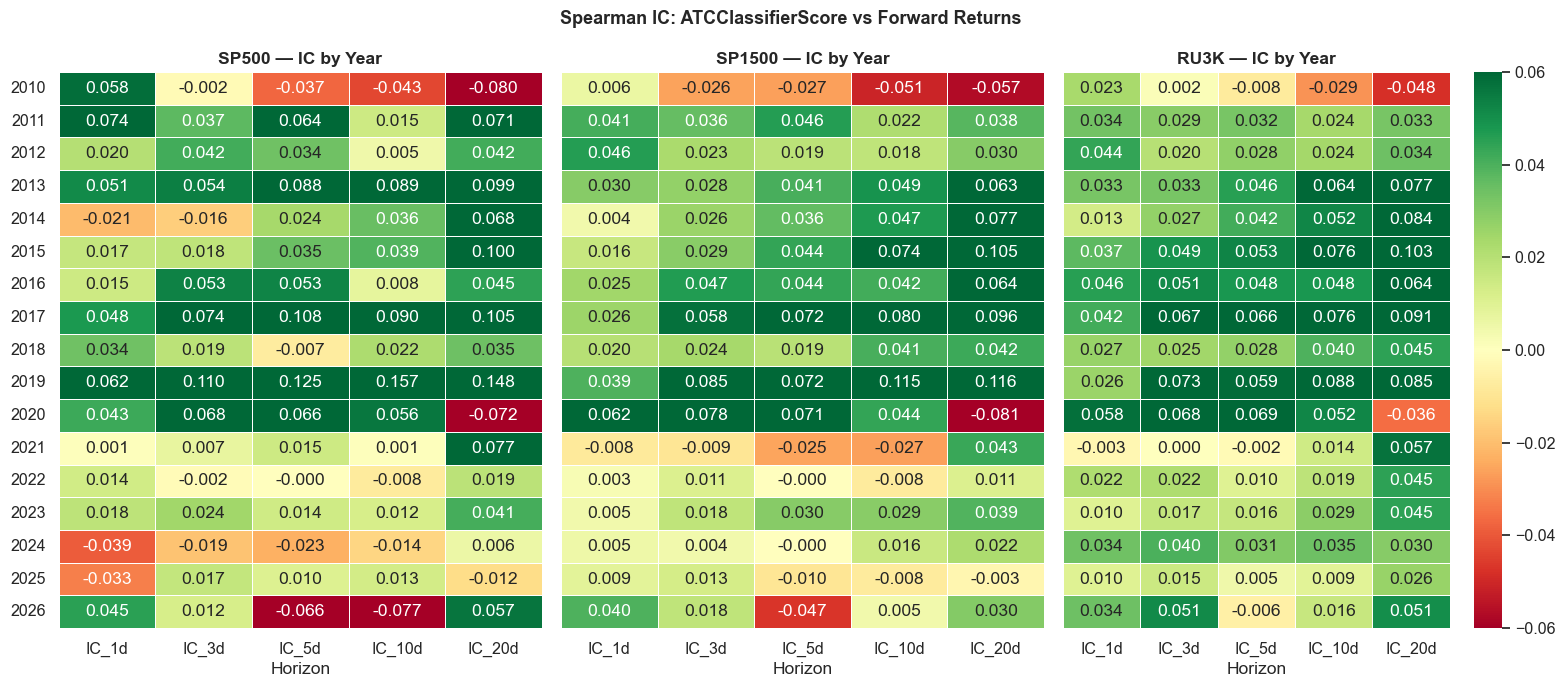

In [3]:
# IC heatmap across all universes and horizons
fig, axes = plt.subplots(1, 3, figsize=(16, 7), sharey=True)

for ax, univ in zip(axes, UNIVERSES):
    ic_df = ic_table(feat_df, 'ATCClassifierScore', univ)
    # Drop summary rows for heatmap
    heatmap_data = ic_df.drop(index=['MEAN','ICIR'], errors='ignore').astype(float)
    sns.heatmap(
        heatmap_data,
        ax=ax, cmap='RdYlGn', center=0, vmin=-0.06, vmax=0.06,
        annot=True, fmt='.3f', linewidths=0.5, cbar=(ax == axes[-1])
    )
    ax.set_title(f'{UNIV_LABELS[univ]} — IC by Year', fontweight='bold')
    ax.set_xlabel('Horizon')
    ax.set_ylabel('')

fig.suptitle('Spearman IC: ATCClassifierScore vs Forward Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_heatmap_atc.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 IC by Sector

Does the signal work uniformly across GICS sectors, or is it driven by a specific sector?  
Concentrated sector alpha is a risk — it may reflect sector-level beta, not stock-specific NLP signal.

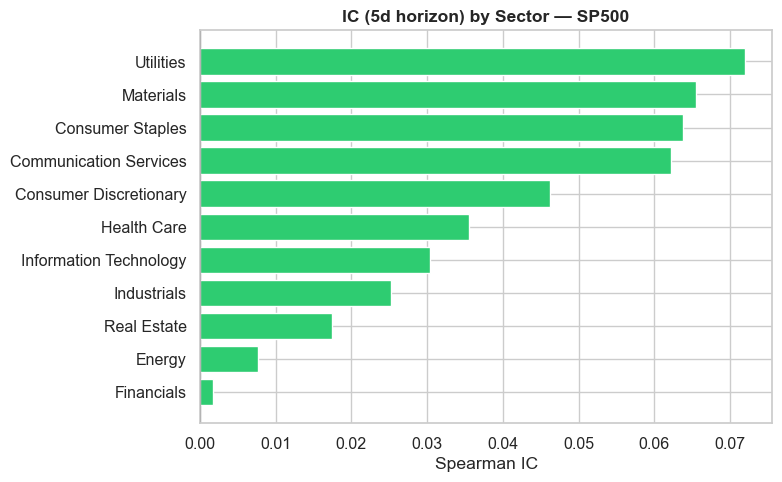

                         IC_5d     N
SECTOR                              
Financials              0.0018  4608
Energy                  0.0077  2008
Real Estate             0.0175  1734
Industrials             0.0252  4670
Information Technology  0.0304  3837
Health Care             0.0355  3861
Consumer Discretionary  0.0462  3796
Communication Services  0.0622  1431
Consumer Staples        0.0638  2581
Materials               0.0655  1765
Utilities               0.0720  1912


In [4]:
def ic_by_sector(df, signal_col, univ_col, horizon=5):
    sub = df[df[univ_col]].copy()
    rows = []
    for sector, grp in sub.groupby('SECTOR'):
        ic = spearman_ic(grp[signal_col], grp[f'fwd_{horizon}d'])
        rows.append({'SECTOR': sector, f'IC_{horizon}d': ic, 'N': len(grp)})
    return pd.DataFrame(rows).set_index('SECTOR').sort_values(f'IC_{horizon}d')

ic_sec = ic_by_sector(feat_df, 'ATCClassifierScore', 'in_sp500', horizon=5)

fig, ax = plt.subplots(figsize=(8, 5))
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in ic_sec['IC_5d'].values]
ax.barh(ic_sec.index, ic_sec['IC_5d'], color=colors)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('IC (5d horizon) by Sector — SP500', fontweight='bold')
ax.set_xlabel('Spearman IC')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()
print(ic_sec.round(4).to_string())

## 4.3 Quintile Portfolio Construction

On each trade date, rank all events in the universe by signal score into 5 quintiles (Q1=lowest, Q5=highest). Hold each quintile for the chosen horizon. Compute:
- **Long-only** (Q5), **short-only** (Q1), **long-short** (Q5 − Q1) cumulative returns
- **Annualised Sharpe** = mean(period_return) / std(period_return) * sqrt(252 / horizon)

We use a **daily rebalance** here (each event trades independently on its entry date).  
Portfolio-level weekly rebalancing is in notebook 06.

In [5]:
def quintile_backtest(df, signal_col, univ_col, horizon=5, n_quantiles=5, tc_bps=5):
    """
    Event-driven quintile backtest.
    Each event is assigned to a quintile on its entry date.
    Returns DataFrame of (period, quintile, avg_return) and summary stats.
    """
    tc_cost = tc_bps / 10000  # one-way
    sub     = df[df[univ_col]].copy()
    ret_col = f'fwd_{horizon}d'
    sub     = sub.dropna(subset=[signal_col, ret_col])

    # Assign quintile cross-sectionally on each entry_date.
    # Guard: skip dates with fewer than n_quantiles events (can't form distinct bins).
    def safe_qcut(s):
        if len(s) < n_quantiles:
            return pd.Series(np.nan, index=s.index)
        try:
            return pd.qcut(s.rank(method='first'), n_quantiles,
                           labels=range(1, n_quantiles + 1), duplicates='drop')
        except ValueError:
            return pd.Series(np.nan, index=s.index)

    sub['quintile'] = sub.groupby('entry_date')[signal_col].transform(safe_qcut)
    sub = sub.dropna(subset=['quintile'])
    sub['quintile'] = sub['quintile'].astype(int)

    # Average return per (period, quintile)
    sub['period'] = sub['entry_date'].dt.to_period('W')
    rets = sub.groupby(['period', 'quintile'])[ret_col].mean().unstack('quintile')
    rets.columns = [f'Q{i}' for i in rets.columns]

    # Long-short = Q_top - Q_bottom (net of 2-way transaction costs)
    top_col = f'Q{n_quantiles}'
    if top_col not in rets.columns or 'Q1' not in rets.columns:
        raise ValueError(f'Not enough quantile columns: {rets.columns.tolist()}')
    rets['LS'] = rets[top_col] - rets['Q1'] - 2 * tc_cost

    # Cumulative returns
    cum = (1 + rets).cumprod() - 1

    # Annualised Sharpe
    periods_per_year = 252 / horizon
    sharpes = {}
    for col in rets.columns:
        r = rets[col].dropna()
        sharpes[col] = r.mean() / (r.std() + 1e-9) * np.sqrt(periods_per_year)

    return rets, cum, sharpes


# Run for SP500, 5-day horizon
rets_sp500, cum_sp500, sh_sp500 = quintile_backtest(
    feat_df, 'ATCClassifierScore', 'in_sp500', horizon=5
)

print('Annualised Sharpe by quintile (SP500, 5d horizon, 5bps tc):')
for k, v in sh_sp500.items():
    print(f'  {k}: {v:.3f}')


Annualised Sharpe by quintile (SP500, 5d horizon, 5bps tc):
  Q1: 0.252
  Q2: 0.444
  Q3: 0.685
  Q4: 0.944
  Q5: 0.994
  LS: 0.551


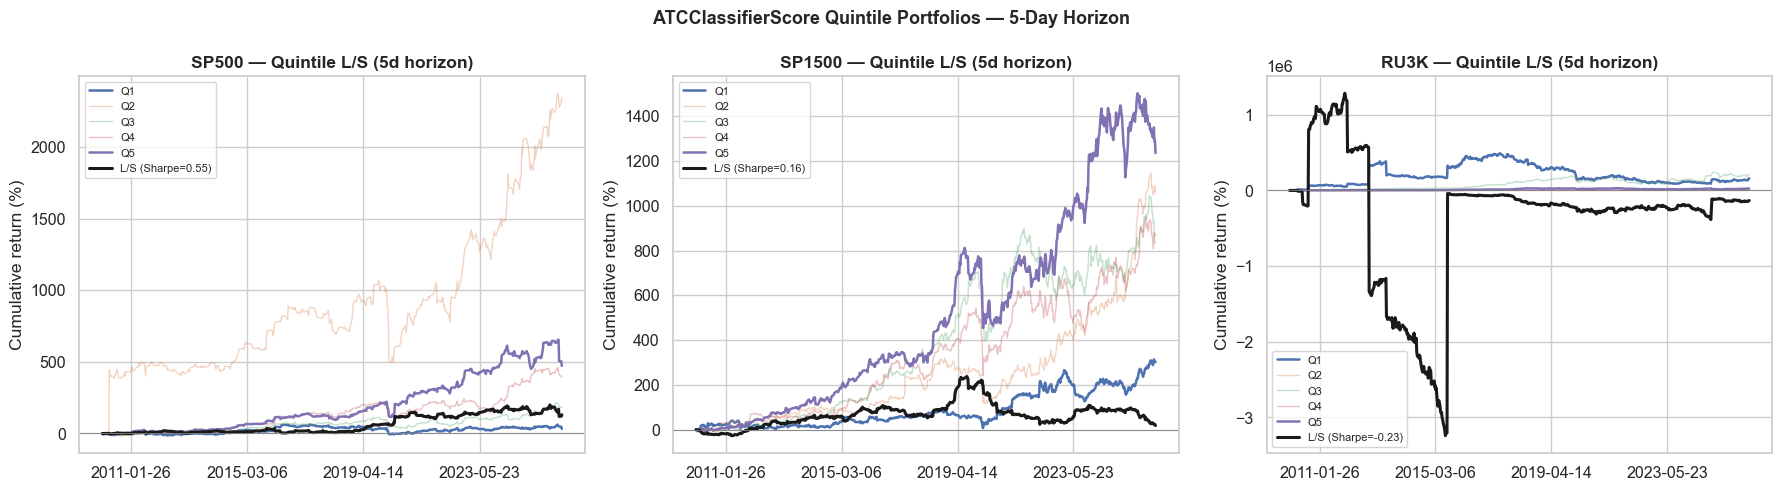

In [6]:
# Quintile spread chart — run all 3 universes × all horizons, show 5d results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, univ in zip(axes, UNIVERSES):
    _, cum, sharpes = quintile_backtest(feat_df, 'ATCClassifierScore', univ, horizon=5)
    label  = UNIV_LABELS[univ]
    ls_sh  = sharpes.get('LS', np.nan)

    for col in [c for c in cum.columns if c.startswith('Q')]:
        alpha = 0.35
        lw    = 1.0
        if col == f'Q{5}':
            alpha, lw = 1.0, 1.8
        elif col == 'Q1':
            alpha, lw = 1.0, 1.8
        ax.plot(cum.index.to_timestamp(), cum[col] * 100, alpha=alpha, lw=lw, label=col)

    ax.plot(cum.index.to_timestamp(), cum['LS'] * 100, 'k-', lw=2.2, label=f'L/S (Sharpe={ls_sh:.2f})')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{label} — Quintile L/S (5d horizon)', fontweight='bold')
    ax.set_ylabel('Cumulative return (%)')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(plt.MaxNLocator(6))

fig.suptitle('ATCClassifierScore Quintile Portfolios — 5-Day Horizon', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'quintile_ls_5d.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Decile Spread + Drawdown Analysis

We also run a **decile** (10-bucket) version. The long-short spread between decile 10 and decile 1 is typically wider than quintile spread — important for understanding signal convexity. We also plot the **rolling drawdown** of the L/S strategy.

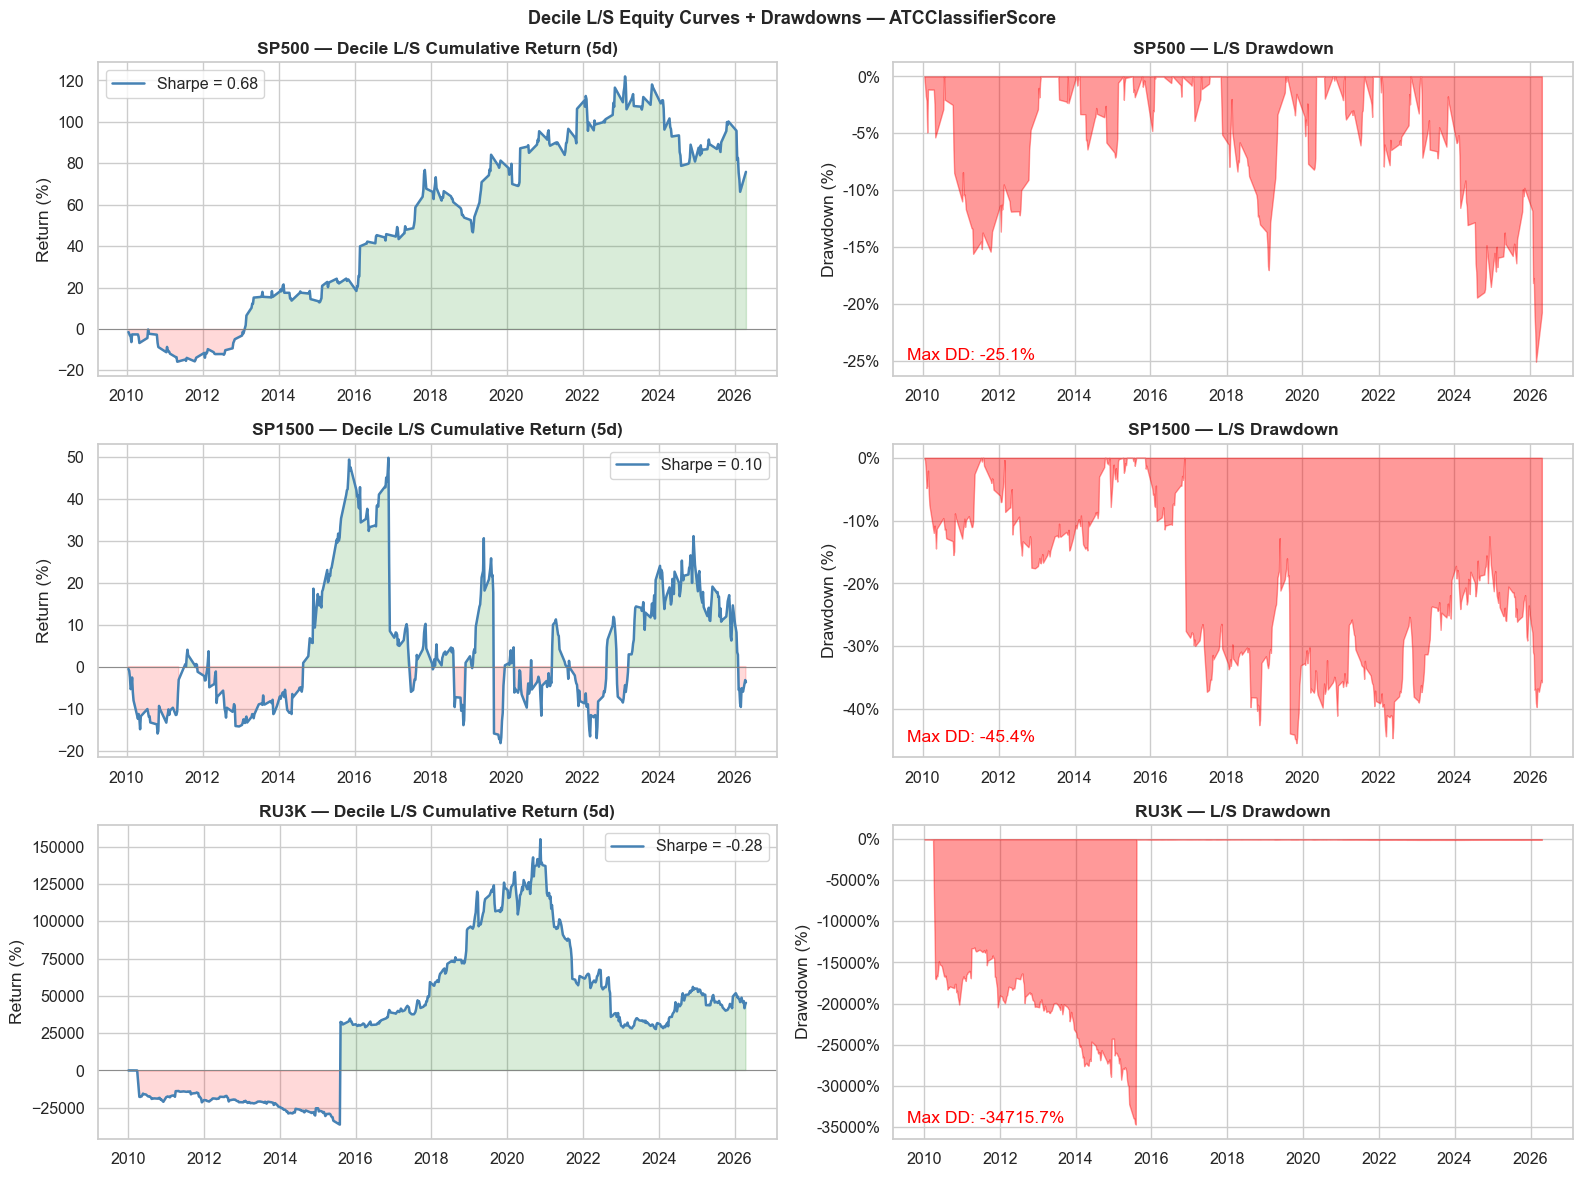

In [7]:
def drawdown_series(cum_ret: pd.Series) -> pd.Series:
    cumval = 1 + cum_ret
    peak   = cumval.expanding().max()
    return (cumval / peak) - 1


fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for row_idx, univ in enumerate(UNIVERSES):
    label = UNIV_LABELS[univ]

    # Decile L/S cumulative return
    _, cum_d, sh_d = quintile_backtest(
        feat_df, 'ATCClassifierScore', univ, horizon=5, n_quantiles=10
    )
    ax = axes[row_idx, 0]
    ax.plot(cum_d.index.to_timestamp(), cum_d['LS'] * 100, 'steelblue', lw=1.8,
            label=f'Sharpe = {sh_d["LS"]:.2f}')
    ax.fill_between(cum_d.index.to_timestamp(), 0, cum_d['LS']*100,
                    where=cum_d['LS']>0, alpha=0.15, color='green')
    ax.fill_between(cum_d.index.to_timestamp(), 0, cum_d['LS']*100,
                    where=cum_d['LS']<0, alpha=0.15, color='red')
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_title(f'{label} — Decile L/S Cumulative Return (5d)', fontweight='bold')
    ax.set_ylabel('Return (%)')
    ax.legend()

    # Drawdown
    ax = axes[row_idx, 1]
    dd = drawdown_series(cum_d['LS'])
    ax.fill_between(dd.index.to_timestamp(), 0, dd*100, color='red', alpha=0.4)
    ax.set_title(f'{label} — L/S Drawdown', fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    max_dd = dd.min()
    ax.text(0.02, 0.05, f'Max DD: {max_dd:.1%}', transform=ax.transAxes, color='red')

fig.suptitle('Decile L/S Equity Curves + Drawdowns — ATCClassifierScore', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'decile_equity_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 IC Decay Curve

How fast does the signal decay? Plot mean IC across all horizons (1→20d). This justifies the choice of target horizon in the walk-forward model. The ATC classifier was trained on a 14-day window so we expect IC to peak somewhere around 5-10d and decay beyond 15d.

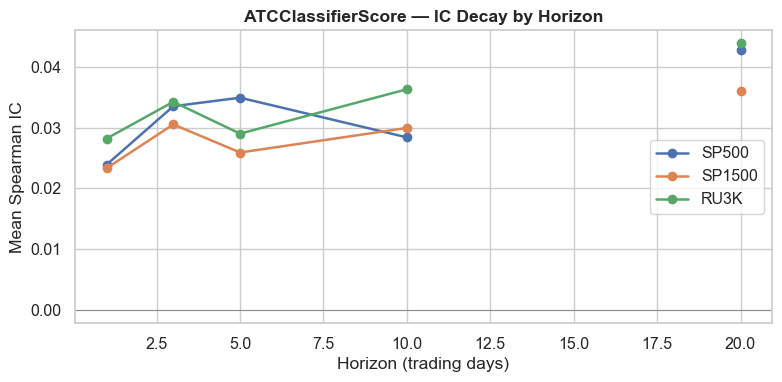

In [8]:
horizons_extended = [1, 3, 5, 10, 15, 20]

fig, ax = plt.subplots(figsize=(8, 4))

for univ in UNIVERSES:
    sub   = feat_df[feat_df[univ]].copy()
    label = UNIV_LABELS[univ]
    ics   = []
    for h in horizons_extended:
        col = f'fwd_{h}d'
        if col not in sub.columns:
            ics.append(np.nan)
            continue
        ics.append(spearman_ic(sub['ATCClassifierScore'], sub[col]))
    ax.plot(horizons_extended, ics, marker='o', label=label, lw=1.8)

ax.axhline(0, color='grey', lw=0.6)
ax.set_xlabel('Horizon (trading days)')
ax.set_ylabel('Mean Spearman IC')
ax.set_title('ATCClassifierScore — IC Decay by Horizon', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ic_decay_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.6 Placebo Test (Red-Team Sanity Check)

Run the same quintile backtest using only the Fluff/Filler-derived signal.  
Expected result: L/S Sharpe ≈ 0, no consistent quintile ordering, no monotone IC.  
If this test fails (material positive Sharpe), there is a look-ahead bug.

=== PLACEBO TEST (Fluff/Filler signal only) ===
Expected: all Sharpes ≈ 0, no trend in cumulative L/S curve



SP500: Sharpe = -0.994  →  FAIL ✗ — CHECK FOR LOOK-AHEAD!


SP1500: Sharpe = -0.825  →  FAIL ✗ — CHECK FOR LOOK-AHEAD!


RU3K: Sharpe = -0.256  →  PASS ✓


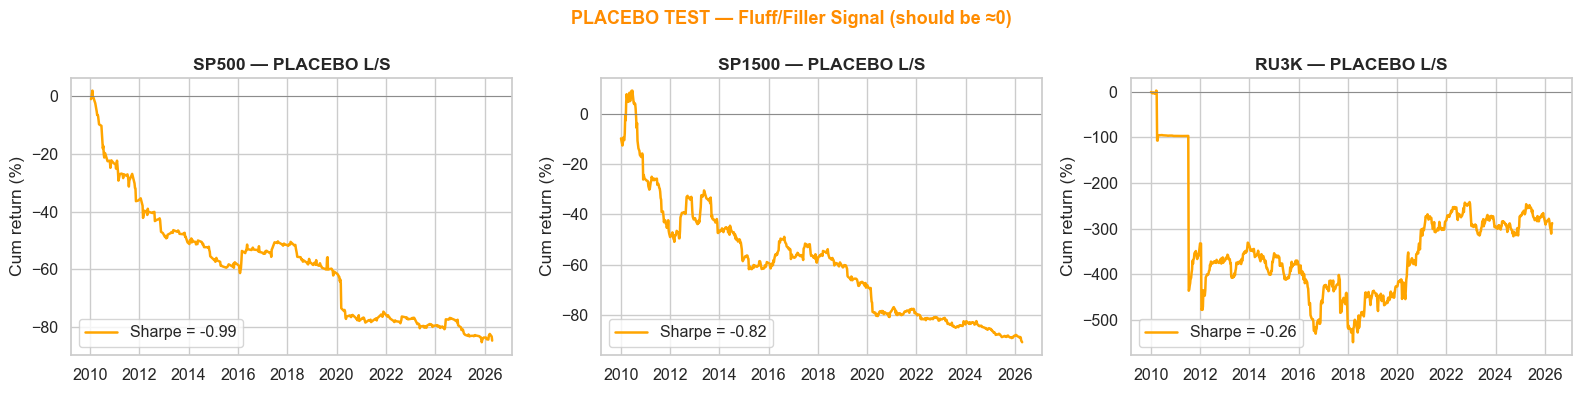

In [9]:
print('=== PLACEBO TEST (Fluff/Filler signal only) ===')
print('Expected: all Sharpes ≈ 0, no trend in cumulative L/S curve')
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, univ in zip(axes, UNIVERSES):
    label = UNIV_LABELS[univ]
    try:
        _, cum_p, sh_p = quintile_backtest(
            placebo_df, 'placebo_signal', univ, horizon=5
        )
        ax.plot(cum_p.index.to_timestamp(), cum_p['LS']*100, 'orange', lw=1.8,
                label=f'Sharpe = {sh_p["LS"]:.2f}')
        ax.axhline(0, color='grey', lw=0.6)
        ax.set_title(f'{label} — PLACEBO L/S', fontweight='bold')
        ax.set_ylabel('Cum return (%)')
        ax.legend()
        status = 'PASS ✓' if abs(sh_p['LS']) < 0.5 else 'FAIL ✗ — CHECK FOR LOOK-AHEAD!'
        print(f'{label}: Sharpe = {sh_p["LS"]:.3f}  →  {status}')
    except Exception as e:
        print(f'{label}: ERROR — {e}')

fig.suptitle('PLACEBO TEST — Fluff/Filler Signal (should be ≈0)', fontsize=13,
             fontweight='bold', color='darkorange')
plt.tight_layout()
plt.savefig(FIG_DIR / 'placebo_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.7 Speaker-Slice Comparison

The handout notes that speaker-specific slices may produce differentiated signals. Compare the IC of `ATCClassifierScore` across Total, CEO, CFO, and Analysts slices — are any slices more informative than the aggregate?

Speaker slice ATC columns found: ['atc_analysts', 'atc_answer', 'atc_ceo', 'atc_cfo', 'atc_presentation', 'atc_question', 'atc_total']



IC by speaker slice — SP500:
                        1d      3d      5d     10d     20d
ATCClassifierScore  0.0239  0.0335  0.0349  0.0284  0.0428
atc_analysts        0.0082  0.0123  0.0079  0.0084  0.0104
atc_answer          0.0158  0.0161  0.0171  0.0041  0.0110
atc_ceo             0.0112  0.0176  0.0131  0.0038  0.0070
atc_cfo            -0.0040  0.0048  0.0043 -0.0049  0.0091
atc_presentation    0.0135  0.0198  0.0184  0.0117  0.0188
atc_question        0.0085  0.0130  0.0083  0.0070  0.0095
atc_total           0.0239  0.0335  0.0349  0.0284  0.0428


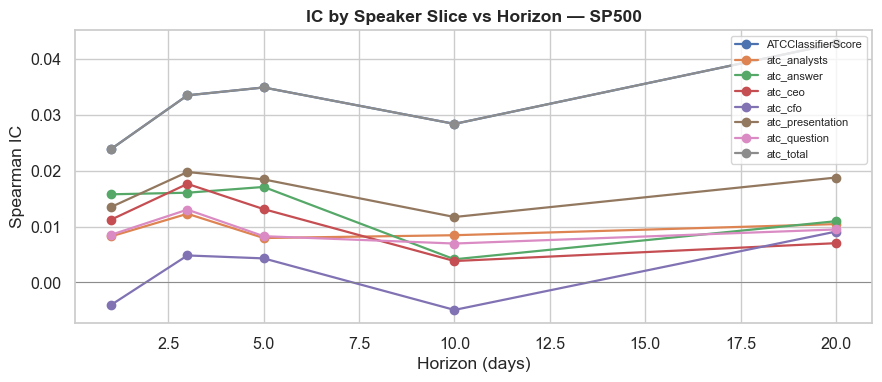

In [10]:
slice_atc_cols = [c for c in feat_df.columns if c.startswith('atc_')]
print('Speaker slice ATC columns found:', slice_atc_cols)

if slice_atc_cols:
    signal_cols = ['ATCClassifierScore'] + slice_atc_cols
    sub = feat_df[feat_df['in_sp500']].copy()

    slice_ic = {}
    for sc in signal_cols:
        slice_ic[sc] = [
            spearman_ic(sub[sc], sub[f'fwd_{h}d'])
            for h in HORIZONS
        ]

    slice_ic_df = pd.DataFrame(slice_ic, index=[f'{h}d' for h in HORIZONS]).T
    print('\nIC by speaker slice — SP500:')
    print(slice_ic_df.round(4).to_string())

    fig, ax = plt.subplots(figsize=(9, 4))
    for sc in signal_cols:
        ax.plot(HORIZONS, slice_ic[sc], marker='o', label=sc, lw=1.6)
    ax.axhline(0, color='grey', lw=0.6)
    ax.set_xlabel('Horizon (days)')
    ax.set_ylabel('Spearman IC')
    ax.set_title('IC by Speaker Slice vs Horizon — SP500', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'ic_by_speaker_slice.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Speaker slice columns not found — re-run notebook 03 first.')